# Analyse de la Performance Commerciale & Segmentation Client
## E-Commerce UK - 2010 / 2011

---

### Contexte métier

Une entreprise britannique de vente en ligne (cadeaux & décoration) souhaite mieux comprendre sa performance commerciale afin d'orienter ses décisions stratégiques pour l'année suivante.

La direction pose quatre questions clés :

1. **Quelle est l'évolution du chiffre d'affaires et de la marge au fil du temps ?**
2. **Quels sont les marchés et produits les plus rentables ?**
3. **Quel est l'impact financier des retours produits ?**
4. **Qui sont nos meilleurs clients et quels segments nécessitent une attention particulière ?**

---

### Structure de l'analyse

| Étape | Description |
|---|---|
| 1 | Chargement & audit de la donnée brute |
| 2 | Nettoyage & standardisation |
| 3 | Feature Engineering |
| 4 | Analyse de la performance commerciale |
| 5 | Analyse des retours produits |
| 6 | Segmentation client RFM |
| 7 | Export des fichiers Power BI |

---

**Source des données :** UCI Machine Learning Repository — Online Retail Dataset  
**Période couverte :** Décembre 2010 — Décembre 2011  
**Volume :** ~541 000 lignes de transactions

## 0. Imports & Configuration

In [1]:
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Style graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# ============================================================
# HYPOTHÈSE MÉTIER : taux de coût estimé à 60% du prix de vente
# => marge brute estimée = 40%
# Source : benchmark e-commerce cadeaux/déco UK (hypothèse de travail)
# ============================================================
COUT_RATIO = 0.60
MARGE_RATIO = 1 - COUT_RATIO

print("Configuration chargée.")
print(f"  Hypothèse marge brute : {MARGE_RATIO:.0%}")

Configuration chargée.
  Hypothèse marge brute : 40%


---
## Étape 1 - Chargement & Audit de la Donnée Brute

In [2]:
dfo = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")

print("=" * 50)
print("AUDIT DE LA DONNÉE BRUTE")
print("=" * 50)

rows, cols = dfo.shape
print(f"\n Dimensions         : {rows:,} lignes × {cols} colonnes")
print(f" Colonnes           : {list(dfo.columns)}")
print(f" Période couverte   : {dfo['InvoiceDate'].min()} → {dfo['InvoiceDate'].max()}")

print("\n--- Valeurs manquantes ---")
missing = dfo.isnull().sum()
missing_pct = (missing / len(dfo) * 100).round(2)
missing_df = pd.DataFrame({"Manquants": missing, "% manquant": missing_pct})
print(missing_df[missing_df["Manquants"] > 0])

print("\n--- Lignes avec quantité négative (retours / annulations) ---")
nb_retours = (dfo["Quantity"] < 0).sum()
nb_annulations = dfo["InvoiceNo"].astype(str).str.startswith("C").sum()
print(f" Lignes quantité < 0       : {nb_retours:,}")
print(f" Factures annulées (C...)  : {nb_annulations:,}")

print("\n--- Aperçu ---")
display(dfo.head(3))

AUDIT DE LA DONNÉE BRUTE

 Dimensions         : 541,909 lignes × 8 colonnes
 Colonnes           : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
 Période couverte   : 2010-12-01 08:26:00 → 2011-12-09 12:50:00

--- Valeurs manquantes ---
             Manquants  % manquant
Description       1454        0.27
CustomerID      135080       24.93

--- Lignes avec quantité négative (retours / annulations) ---
 Lignes quantité < 0       : 10,624
 Factures annulées (C...)  : 9,288

--- Aperçu ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


---
## Étape 2 - Nettoyage & Standardisation

**Règles appliquées :**
- Renommage des colonnes en français (convention interne)
- Conversion des types (date, entier client)
- Suppression des lignes sans `CustomerID` (transactions non traçables)
- Suppression des `UnitPrice` nuls ou négatifs (données corrompues)
- Isolation des retours dans un DataFrame dédié `df_retours` (conservé pour analyse)

In [3]:
df_raw = dfo.copy()

# --- Renommage ---
df_raw = df_raw.rename(columns={
    "InvoiceNo"  : "FACTURE",
    "StockCode"  : "CODE_PRODUIT",
    "Description": "LIBELLE_PRODUIT",
    "Quantity"   : "QUANTITE",
    "InvoiceDate": "DATE_FACTURE",
    "UnitPrice"  : "PRIX_UNITAIRE",
    "CustomerID" : "ID_CLIENT",
    "Country"    : "PAYS"
})

# --- Typage ---
df_raw["DATE_FACTURE"] = pd.to_datetime(df_raw["DATE_FACTURE"])
df_raw["ID_CLIENT"]    = df_raw["ID_CLIENT"].astype("Int64")  # Int64 supporte les NaN
df_raw["FACTURE"]      = df_raw["FACTURE"].astype(str)
df_raw["LIBELLE_PRODUIT"] = df_raw["LIBELLE_PRODUIT"].str.strip().str.upper()

# --- Flag retour ---
df_raw["EST_RETOUR"] = df_raw["FACTURE"].str.startswith("C") | (df_raw["QUANTITE"] < 0)

# --- Isolation retours ---
df_retours = df_raw[df_raw["EST_RETOUR"]].copy()

# --- Données nettoyées (ventes uniquement) ---
df = df_raw[
    (~df_raw["EST_RETOUR"]) &
    (df_raw["ID_CLIENT"].notna()) &
    (df_raw["PRIX_UNITAIRE"] > 0) &
    (df_raw["QUANTITE"] > 0)
].copy()

print("=" * 50)
print("RÉSULTAT DU NETTOYAGE")
print("=" * 50)
print(f"\n Lignes brutes           : {len(dfo):,}")
print(f" → Retours / annulations : {len(df_retours):,}  ({len(df_retours)/len(dfo)*100:.1f}%)")
print(f" → Sans CustomerID       : {df_raw[df_raw['ID_CLIENT'].isna() & ~df_raw['EST_RETOUR']].shape[0]:,}")
print(f" → Prix unitaire <= 0    : {df_raw[(df_raw['PRIX_UNITAIRE'] <= 0) & ~df_raw['EST_RETOUR']].shape[0]:,}")
print(f"\n Lignes après nettoyage  : {len(df):,}")
print(f" Clients distincts       : {df['ID_CLIENT'].nunique():,}")
print(f" Produits distincts      : {df['CODE_PRODUIT'].nunique():,}")
print(f" Pays couverts           : {df['PAYS'].nunique():,}")

RÉSULTAT DU NETTOYAGE

 Lignes brutes           : 541,909
 → Retours / annulations : 10,624  (2.0%)
 → Sans CustomerID       : 133,361
 → Prix unitaire <= 0    : 1,181

 Lignes après nettoyage  : 397,884
 Clients distincts       : 4,338
 Produits distincts      : 3,665
 Pays couverts           : 37


---
## Étape 3 - Feature Engineering

Construction des indicateurs nécessaires à l'analyse et au dashboard Power BI.

In [4]:
# ============================================================
# FEATURES TEMPORELLES
# ============================================================
df["ANNEE"]       = df["DATE_FACTURE"].dt.year
df["MOIS"]        = df["DATE_FACTURE"].dt.month
df["ANNEE_MOIS"]  = df["DATE_FACTURE"].dt.to_period("M").astype(str)
df["SEMAINE"]     = df["DATE_FACTURE"].dt.isocalendar().week.astype(int)
df["JOUR_SEMAINE"] = df["DATE_FACTURE"].dt.day_name()
df["HEURE"]       = df["DATE_FACTURE"].dt.hour
df["TRIMESTRE"]   = df["DATE_FACTURE"].dt.quarter

# ============================================================
# INDICATEURS FINANCIERS
# ============================================================
df["CA"]          = df["QUANTITE"] * df["PRIX_UNITAIRE"]
df["COUT_ESTIME"] = df["CA"] * COUT_RATIO
df["MARGE"]       = df["CA"] * MARGE_RATIO
df["TAUX_MARGE"]  = MARGE_RATIO  # uniforme par hypothèse

# ============================================================
# FLAG GÉOGRAPHIQUE
# ============================================================
df["ZONE"] = df["PAYS"].apply(lambda x: "UK" if x == "United Kingdom" else "Export")

print("Feature engineering terminé.")
print(f"\nColonnes disponibles : {list(df.columns)}")
display(df[["FACTURE", "DATE_FACTURE", "ANNEE_MOIS", "CODE_PRODUIT",
            "QUANTITE", "PRIX_UNITAIRE", "CA", "MARGE", "PAYS", "ZONE"]].head(4))

Feature engineering terminé.

Colonnes disponibles : ['FACTURE', 'CODE_PRODUIT', 'LIBELLE_PRODUIT', 'QUANTITE', 'DATE_FACTURE', 'PRIX_UNITAIRE', 'ID_CLIENT', 'PAYS', 'EST_RETOUR', 'ANNEE', 'MOIS', 'ANNEE_MOIS', 'SEMAINE', 'JOUR_SEMAINE', 'HEURE', 'TRIMESTRE', 'CA', 'COUT_ESTIME', 'MARGE', 'TAUX_MARGE', 'ZONE']


,FACTURE,DATE_FACTURE,ANNEE_MOIS,CODE_PRODUIT,QUANTITE,PRIX_UNITAIRE,CA,MARGE,PAYS,ZONE
0,536365,2010-12-01 08:26:00,2010-12,85123A,6,2.55,15.30,6.120,United Kingdom,UK
1,536365,2010-12-01 08:26:00,2010-12,71053,6,3.39,20.34,8.136,United Kingdom,UK
2,536365,2010-12-01 08:26:00,2010-12,84406B,8,2.75,22.00,8.800,United Kingdom,UK
3,536365,2010-12-01 08:26:00,2010-12,84029G,6,3.39,20.34,8.136,United Kingdom,UK


---
## Étape 4 - Performance Commerciale

### 4.1 Vue d'ensemble : KPIs globaux

In [5]:
ca_total     = df["CA"].sum()
marge_totale = df["MARGE"].sum()
nb_commandes = df["FACTURE"].nunique()
nb_clients   = df["ID_CLIENT"].nunique()
panier_moyen = ca_total / nb_commandes

print("=" * 50)
print("KPIs GLOBAUX — VENTES 2010-2011")
print("=" * 50)
print(f"  CA total         : £{ca_total:>12,.0f}")
print(f"  Marge estimée    : £{marge_totale:>12,.0f}  ({MARGE_RATIO:.0%} du CA)")
print(f"  Nb commandes     :  {nb_commandes:>12,}")
print(f"  Nb clients actifs:  {nb_clients:>12,}")
print(f"  Panier moyen     : £{panier_moyen:>12,.2f}")

KPIs GLOBAUX — VENTES 2010-2011
  CA total         : £   8,911,408
  Marge estimée    : £   3,564,563  (40% du CA)
  Nb commandes     :        18,532
  Nb clients actifs:         4,338
  Panier moyen     : £      480.87


### 4.2 Évolution mensuelle du CA et de la Marge

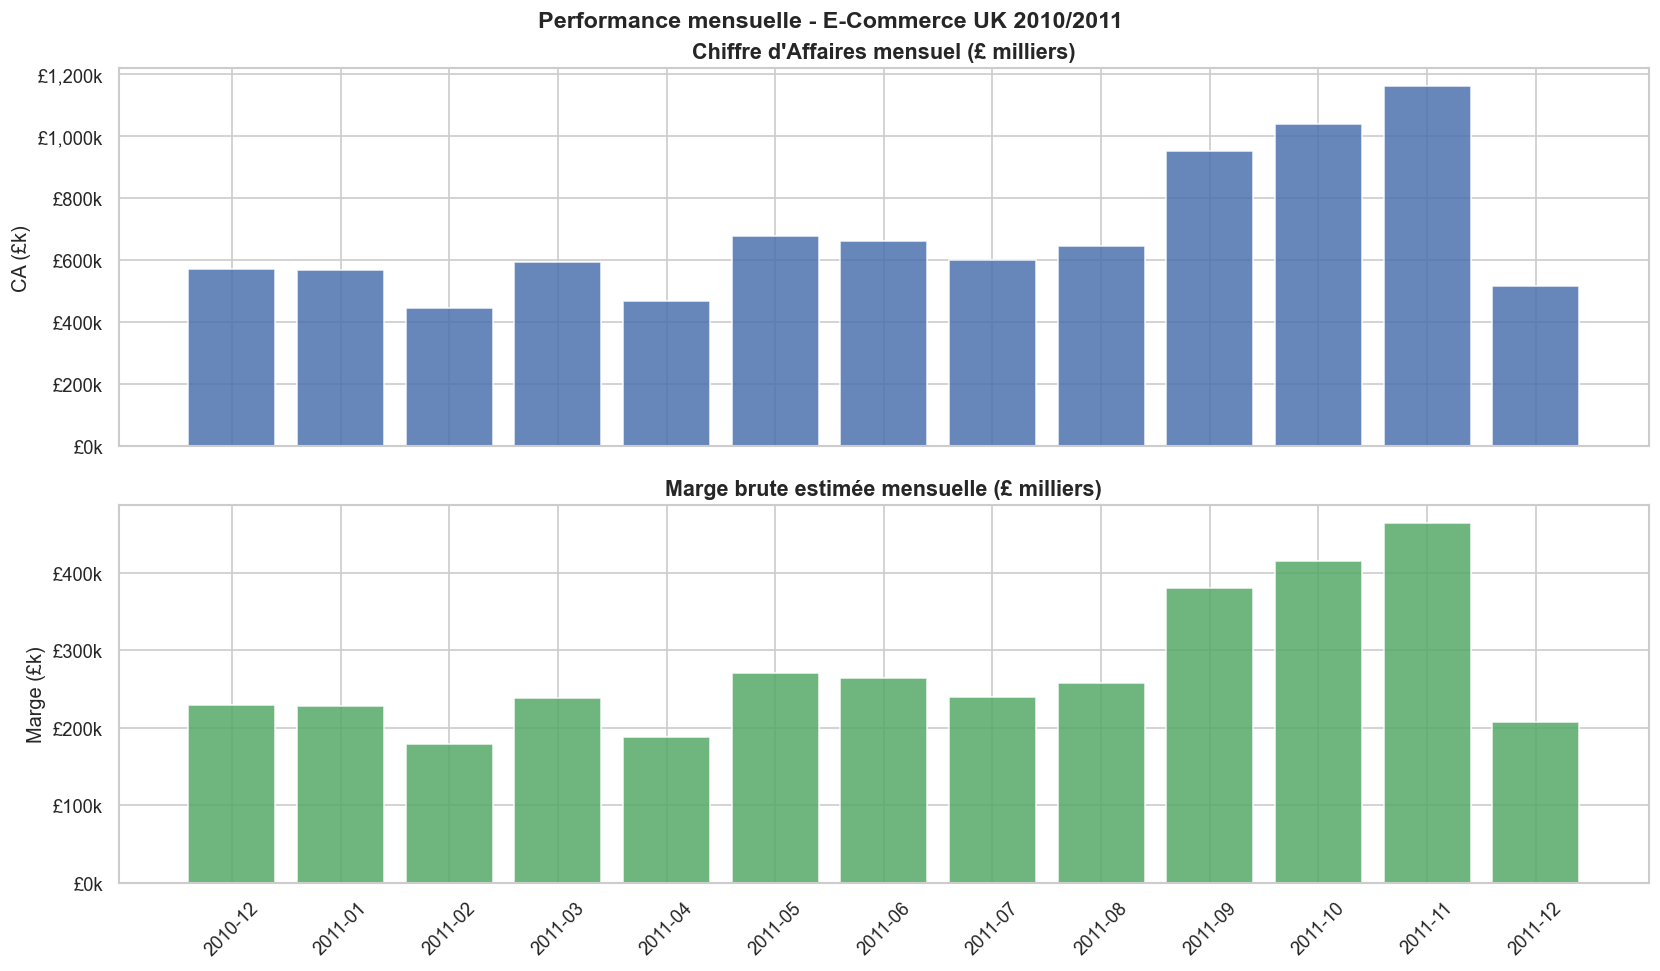


Observation : Forte saisonnalité en novembre/décembre — pic de fin d'année typique du retail cadeaux.


In [7]:
monthly = df.groupby("ANNEE_MOIS").agg(
    CA=("CA", "sum"),
    MARGE=("MARGE", "sum"),
    NB_COMMANDES=("FACTURE", "nunique")
).reset_index().sort_values("ANNEE_MOIS")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(monthly["ANNEE_MOIS"], monthly["CA"] / 1000, color="#4C72B0", alpha=0.85)
axes[0].set_title("Chiffre d'Affaires mensuel (£ milliers)", fontsize=13, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
axes[0].set_ylabel("CA (£k)")

axes[1].bar(monthly["ANNEE_MOIS"], monthly["MARGE"] / 1000, color="#55A868", alpha=0.85)
axes[1].set_title("Marge brute estimée mensuelle (£ milliers)", fontsize=13, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
axes[1].set_ylabel("Marge (£k)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.suptitle("Performance mensuelle - E-Commerce UK 2010/2011",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

print("\nObservation : Forte saisonnalité en novembre/décembre — pic de fin d'année typique du retail cadeaux.")

### 4.3 Performance par Pays (Top 10)

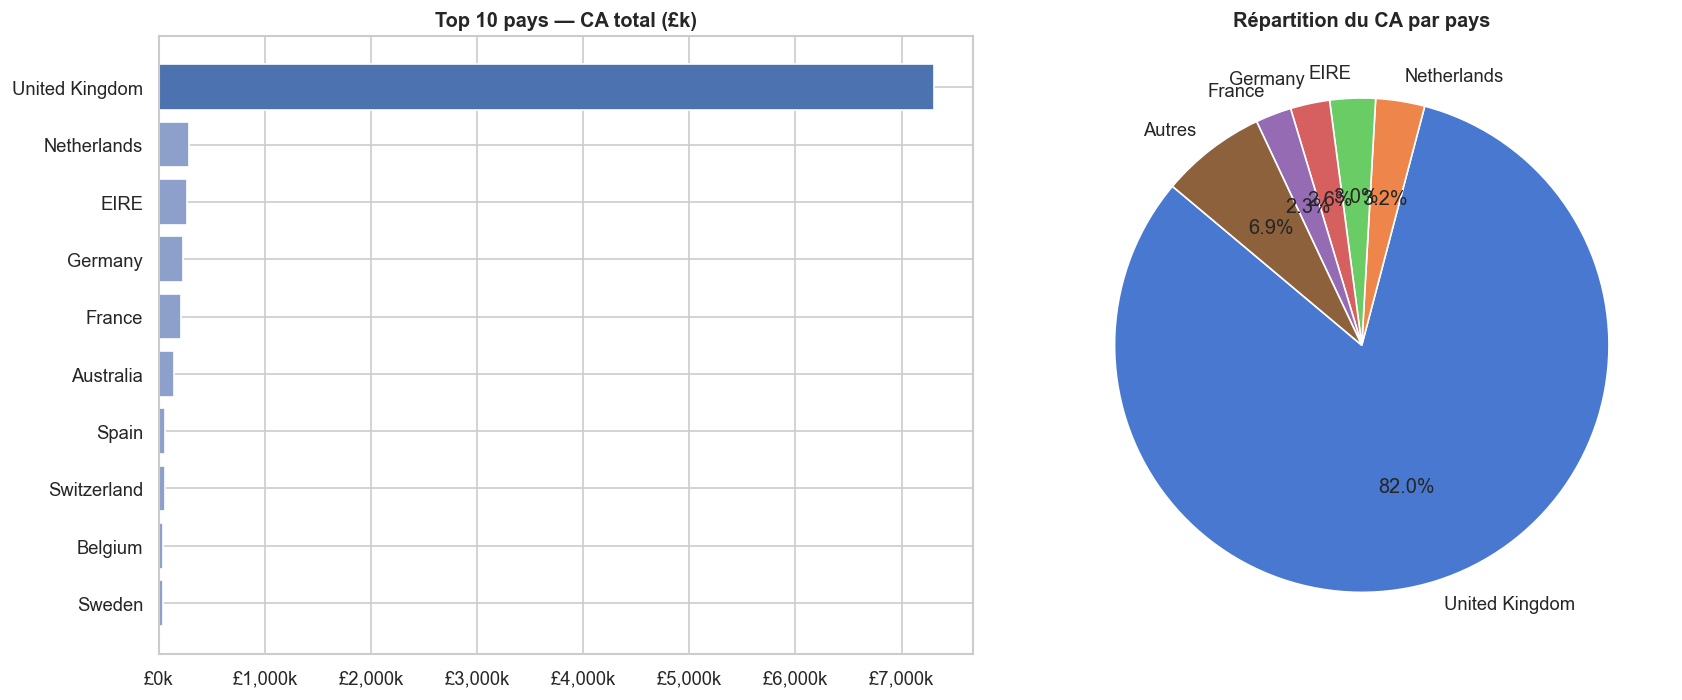


 Le Royaume-Uni représente 82.0% du CA total.
 L'export représente un levier de diversification à surveiller.


In [8]:
pays_perf = df.groupby("PAYS").agg(
    CA=("CA", "sum"),
    MARGE=("MARGE", "sum"),
    NB_CLIENTS=("ID_CLIENT", "nunique"),
    NB_COMMANDES=("FACTURE", "nunique")
).reset_index()

pays_perf["PART_CA_%"] = pays_perf["CA"] / pays_perf["CA"].sum() * 100
pays_perf["PANIER_MOYEN"] = pays_perf["CA"] / pays_perf["NB_COMMANDES"]
top10_pays = pays_perf.sort_values("CA", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CA par pays
colors = ["#4C72B0" if p == "United Kingdom" else "#8DA0CB" for p in top10_pays["PAYS"]]
axes[0].barh(top10_pays["PAYS"][::-1], top10_pays["CA"][::-1] / 1000, color=colors[::-1])
axes[0].set_title("Top 10 pays — CA total (£k)", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))

# Part du CA
top5_pays = pays_perf.sort_values("CA", ascending=False).head(5)
autres_ca = pays_perf.sort_values("CA", ascending=False).iloc[5:]["CA"].sum()
pie_data  = pd.concat([top5_pays[["PAYS", "CA"]],
                        pd.DataFrame({"PAYS": ["Autres"], "CA": [autres_ca]})])
axes[1].pie(pie_data["CA"], labels=pie_data["PAYS"], autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("muted", len(pie_data)))
axes[1].set_title("Répartition du CA par pays", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\n Le Royaume-Uni représente {pays_perf[pays_perf['PAYS']=='United Kingdom']['PART_CA_%'].values[0]:.1f}% du CA total.")
print(" L'export représente un levier de diversification à surveiller.")

### 4.4 Top Produits - CA & Volume

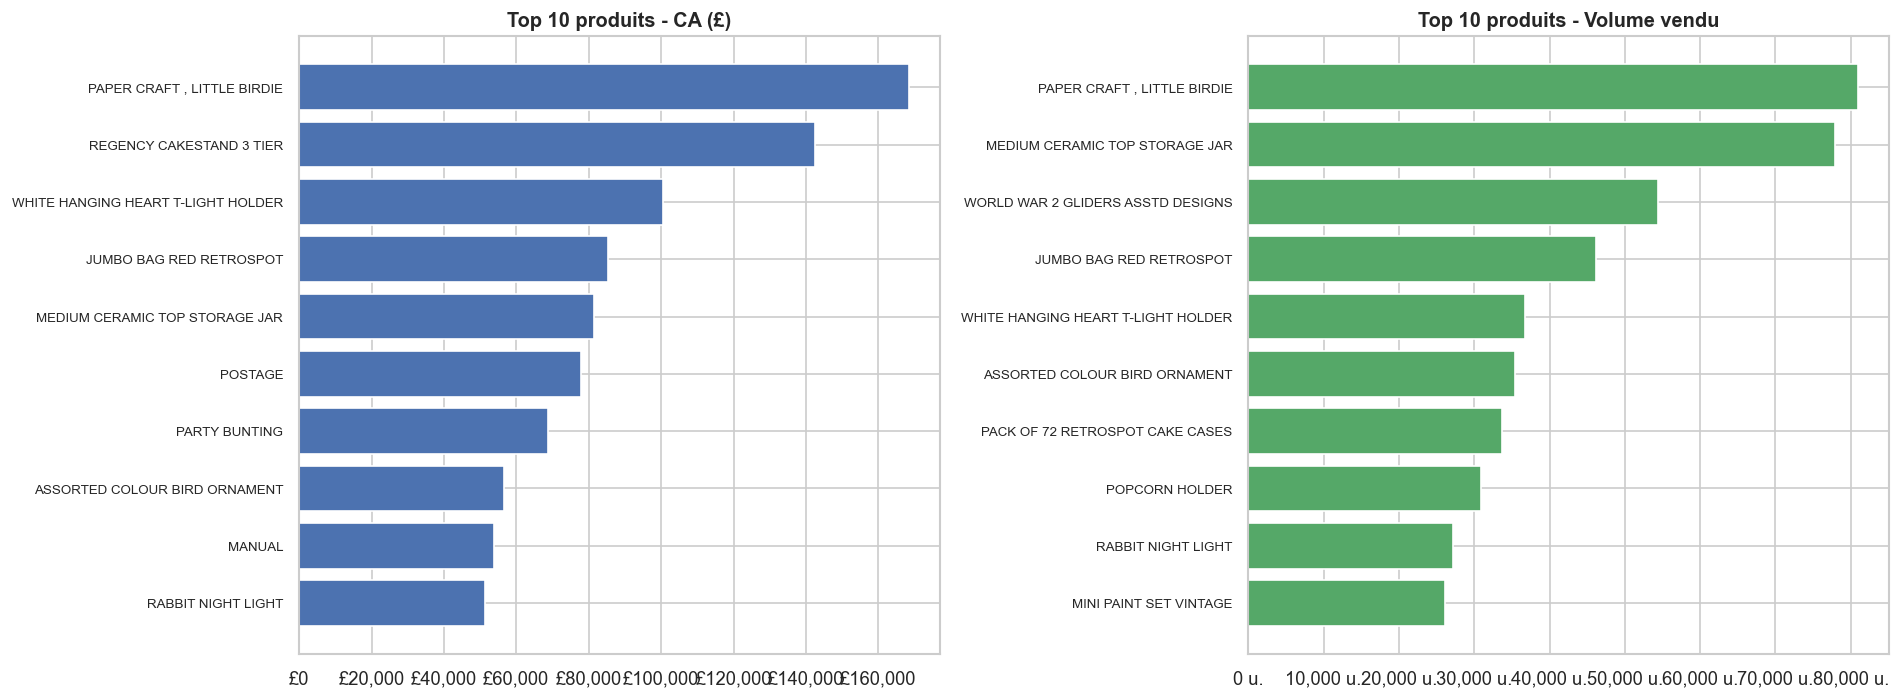

In [10]:
produits = df.groupby(["CODE_PRODUIT", "LIBELLE_PRODUIT"]).agg(
    CA=("CA", "sum"),
    QUANTITE=("QUANTITE", "sum"),
    MARGE=("MARGE", "sum"),
    NB_COMMANDES=("FACTURE", "nunique")
).reset_index().sort_values("CA", ascending=False)

top10_ca  = produits.head(10)
top10_qty = produits.sort_values("QUANTITE", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_ca["LIBELLE_PRODUIT"][::-1], top10_ca["CA"][::-1], color="#4C72B0")
axes[0].set_title("Top 10 produits - CA (£)", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

axes[1].barh(top10_qty["LIBELLE_PRODUIT"][::-1], top10_qty["QUANTITE"][::-1], color="#55A868")
axes[1].set_title("Top 10 produits - Volume vendu", fontsize=12, fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} u."))

for ax in axes:
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

### 4.5 Saisonnalité - Heatmap Mois × Jour de la semaine

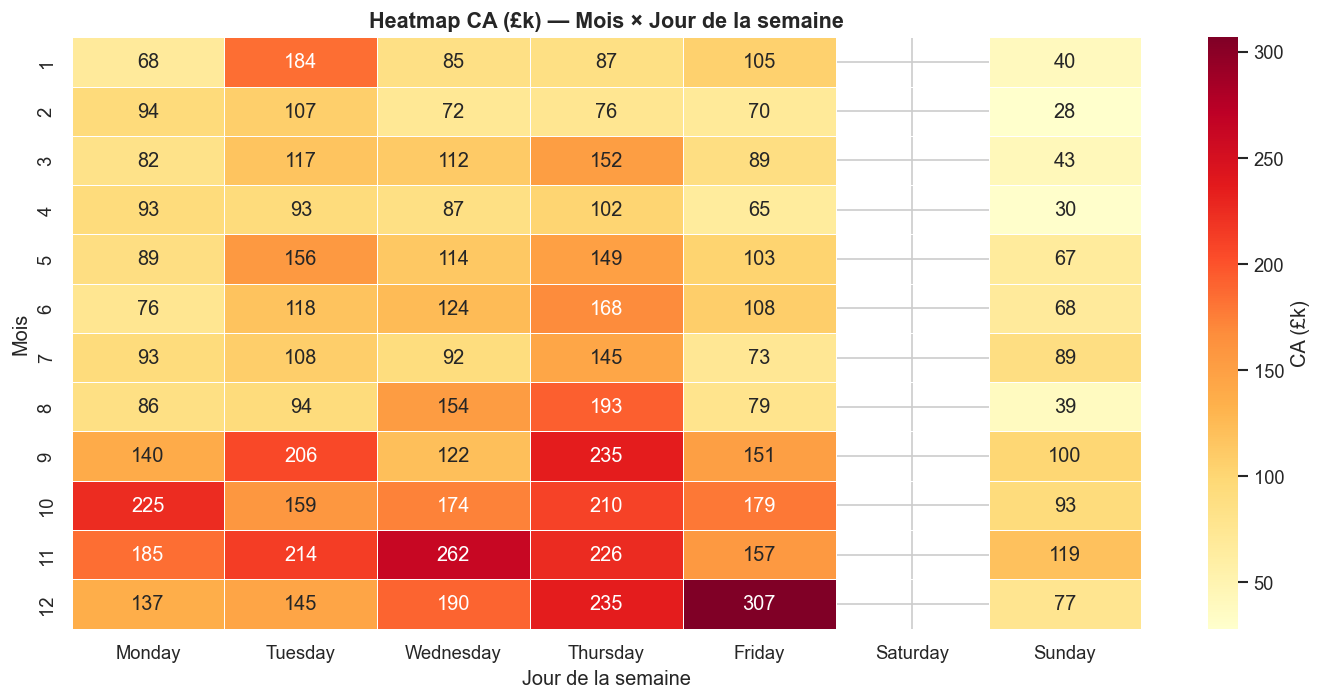


Observation : Les jeudis et mardis génèrent le plus de CA. Le samedi est quasi inexistant (B2B ?).


In [11]:
order_jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap_data = df.groupby(["MOIS", "JOUR_SEMAINE"])["CA"].sum().reset_index()
heatmap_pivot = heatmap_data.pivot(index="MOIS", columns="JOUR_SEMAINE", values="CA").reindex(columns=order_jours)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_pivot / 1000, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "CA (£k)"})
plt.title("Heatmap CA (£k) — Mois × Jour de la semaine", fontsize=13, fontweight="bold")
plt.xlabel("Jour de la semaine")
plt.ylabel("Mois")
plt.tight_layout()
plt.show()

print("\nObservation : Les jeudis et mardis génèrent le plus de CA. Le samedi est quasi inexistant (B2B ?).")

---
## Étape 5 - Analyse des Retours Produits

Les retours sont un facteur clé de dégradation de la marge. On analyse ici leur poids financier et les produits les plus concernés.

In [12]:
# ============================================================
# IMPACT FINANCIER DES RETOURS
# ============================================================
df_retours["CA_RETOUR"] = df_retours["QUANTITE"].abs() * df_retours["PRIX_UNITAIRE"]
df_retours["MARGE_PERDUE"] = df_retours["CA_RETOUR"] * MARGE_RATIO

ca_retours_total    = df_retours["CA_RETOUR"].sum()
marge_perdue_totale = df_retours["MARGE_PERDUE"].sum()
taux_retour_ca      = ca_retours_total / (ca_total + ca_retours_total) * 100

print("=" * 50)
print("IMPACT FINANCIER DES RETOURS")
print("=" * 50)
print(f"  CA retourné          : £{ca_retours_total:>10,.0f}")
print(f"  Marge perdue estimée : £{marge_perdue_totale:>10,.0f}")
print(f"  Taux de retour (CA)  :  {taux_retour_ca:>9.1f}%")
print(f"  Nb lignes de retour  :  {len(df_retours):>9,}")

# ============================================================
# SIMULATION : impact d'une réduction des retours
# ============================================================
scenarios = {
    "Situation actuelle"    : 0,
    "Retours réduits de 25%" : 0.25,
    "Retours réduits de 50%" : 0.50,
    "Retours éliminés"      : 1.00,
}

print("\n--- Simulation d'amélioration de la marge ---")
for label, taux_reduction in scenarios.items():
    marge_recuperee = marge_perdue_totale * taux_reduction
    nouvelle_marge  = marge_totale + marge_recuperee
    gain_pct        = marge_recuperee / marge_totale * 100
    print(f"  {label:<30} → Marge : £{nouvelle_marge:>10,.0f}  (+{gain_pct:.1f}%)")

IMPACT FINANCIER DES RETOURS
  CA retourné          : £   896,812
  Marge perdue estimée : £   358,725
  Taux de retour (CA)  :        9.1%
  Nb lignes de retour  :     10,624

--- Simulation d'amélioration de la marge ---
  Situation actuelle             → Marge : £ 3,564,563  (+0.0%)
  Retours réduits de 25%         → Marge : £ 3,654,244  (+2.5%)
  Retours réduits de 50%         → Marge : £ 3,743,926  (+5.0%)
  Retours éliminés               → Marge : £ 3,923,288  (+10.1%)


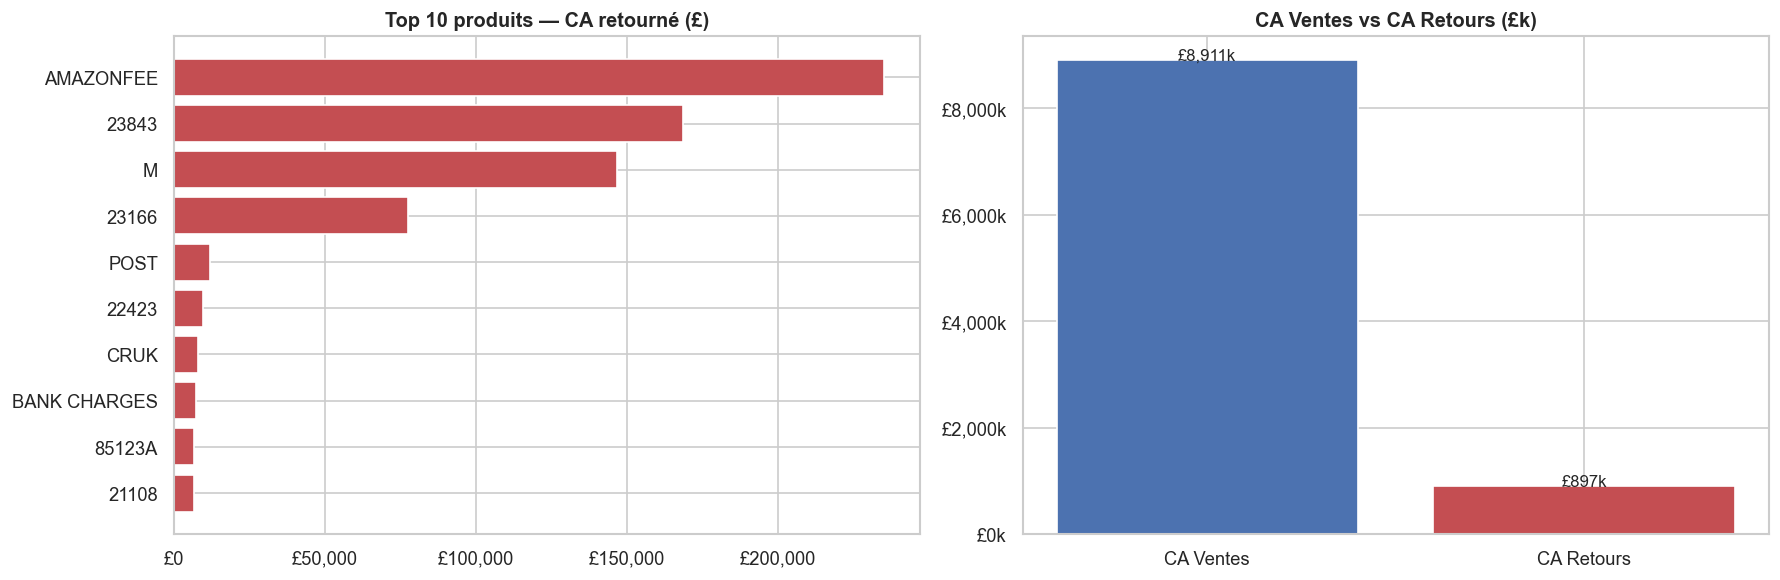

In [13]:
# Top produits retournés
top_retours = (
    df_retours.groupby("CODE_PRODUIT")
    .agg(CA_RETOUR=("CA_RETOUR", "sum"), QTE_RETOURNEE=("QUANTITE", lambda x: x.abs().sum()))
    .reset_index()
    .sort_values("CA_RETOUR", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_retours["CODE_PRODUIT"][::-1], top_retours["CA_RETOUR"][::-1], color="#C44E52")
axes[0].set_title("Top 10 produits — CA retourné (£)", fontsize=12, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# Répartition CA ventes vs retours
axes[1].bar(["CA Ventes", "CA Retours"], [ca_total / 1000, ca_retours_total / 1000],
            color=["#4C72B0", "#C44E52"])
axes[1].set_title("CA Ventes vs CA Retours (£k)", fontsize=12, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}k"))
for bar, val in zip(axes[1].patches, [ca_total, ca_retours_total]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"£{val/1000:,.0f}k", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## Étape 6 - Segmentation Client RFM

L'analyse **RFM (Récence / Fréquence / Montant)** est la méthode de référence en CRM pour qualifier la valeur client.

| Dimension | Définition |
|---|---|
| **R — Récence** | Nombre de jours depuis le dernier achat (plus c'est bas, mieux c'est) |
| **F — Fréquence** | Nombre de commandes distinctes sur la période |
| **M — Montant** | CA total généré par le client |

In [14]:
date_ref = df["DATE_FACTURE"].max() + pd.Timedelta(days=1)

rfm = df.groupby("ID_CLIENT").agg(
    RECENCY  =("DATE_FACTURE", lambda x: (date_ref - x.max()).days),
    FREQUENCY=("FACTURE",      "nunique"),
    MONETARY =("CA",           "sum")
).reset_index()

# --- Scoring 1-4 (4 = meilleur) ---
rfm["R_SCORE"] = pd.qcut(rfm["RECENCY"],                          4, labels=[4, 3, 2, 1])
rfm["F_SCORE"] = pd.qcut(rfm["FREQUENCY"].rank(method="first"),   4, labels=[1, 2, 3, 4])
rfm["M_SCORE"] = pd.qcut(rfm["MONETARY"],                         4, labels=[1, 2, 3, 4])

rfm["RFM_SCORE"] = rfm["R_SCORE"].astype(str) + rfm["F_SCORE"].astype(str) + rfm["M_SCORE"].astype(str)

# --- Segmentation métier ---
def segment_client(row):
    r, f, m = int(row["R_SCORE"]), int(row["F_SCORE"]), int(row["M_SCORE"])
    if r == 4 and f >= 3 and m >= 3:
        return "VIP"
    elif r >= 3 and f >= 3:
        return "Fidèles"
    elif r <= 2 and f >= 2:
        return "À risque"
    elif r == 1:
        return "Inactifs"
    else:
        return "Occasionnels"

rfm["SEGMENT"] = rfm.apply(segment_client, axis=1)

# --- Analyse par segment ---
rfm_summary = rfm.groupby("SEGMENT").agg(
    NB_CLIENTS=("ID_CLIENT",  "count"),
    CA_TOTAL  =("MONETARY",   "sum"),
    RECENCY_MOY=("RECENCY",   "mean"),
    FREQ_MOY  =("FREQUENCY",  "mean"),
    PANIER_MOY=("MONETARY",   "mean")
).reset_index()

rfm_summary["PART_CA_%"] = (rfm_summary["CA_TOTAL"] / rfm_summary["CA_TOTAL"].sum() * 100).round(1)
rfm_summary["PART_CLIENTS_%"] = (rfm_summary["NB_CLIENTS"] / rfm_summary["NB_CLIENTS"].sum() * 100).round(1)

print("=" * 65)
print("ANALYSE RFM — RÉPARTITION PAR SEGMENT")
print("=" * 65)
display(rfm_summary.sort_values("CA_TOTAL", ascending=False).round(1))

ANALYSE RFM — RÉPARTITION PAR SEGMENT


,SEGMENT,NB_CLIENTS,CA_TOTAL,RECENCY_MOY,FREQ_MOY,PANIER_MOY,PART_CA_%,PART_CLIENTS_%
3,VIP,799,4911048.5,8.0,11.3,6146.5,55.1,18.4
0,Fidèles,724,1690326.6,28.5,5.5,2334.7,19.0,16.7
4,À risque,1324,1411762.2,147.3,2.8,1066.3,15.8,30.5
2,Occasionnels,972,647589.8,44.2,1.3,666.2,7.3,22.4
1,Inactifs,519,250680.7,262.9,1.0,483.0,2.8,12.0


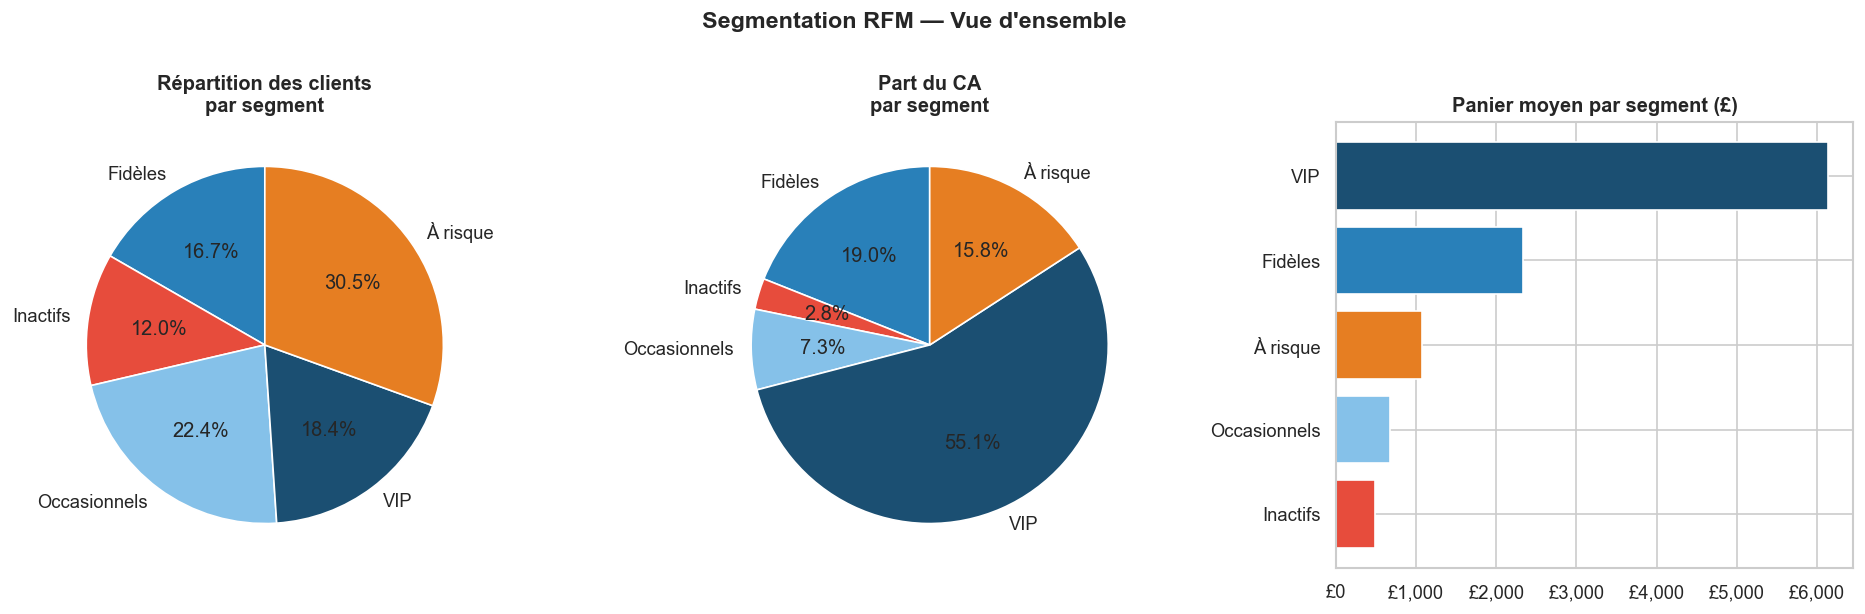


 Insight clé : les clients VIP (18.4% des clients) génèrent 55.1% du CA.
 → Concentration de valeur typique d'un portefeuille e-commerce B2C/B2B mixte.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = {"VIP": "#1b4f72", "Fidèles": "#2980b9", "Occasionnels": "#85c1e9",
           "À risque": "#e67e22", "Inactifs": "#e74c3c"}

# Répartition clients
axes[0].pie(rfm_summary["NB_CLIENTS"],
            labels=rfm_summary["SEGMENT"],
            autopct="%1.1f%%",
            colors=[palette.get(s, "grey") for s in rfm_summary["SEGMENT"]],
            startangle=90)
axes[0].set_title("Répartition des clients\npar segment", fontweight="bold")

# Part du CA
axes[1].pie(rfm_summary["CA_TOTAL"],
            labels=rfm_summary["SEGMENT"],
            autopct="%1.1f%%",
            colors=[palette.get(s, "grey") for s in rfm_summary["SEGMENT"]],
            startangle=90)
axes[1].set_title("Part du CA\npar segment", fontweight="bold")

# Panier moyen
rfm_sorted = rfm_summary.sort_values("PANIER_MOY", ascending=True)
bars = axes[2].barh(rfm_sorted["SEGMENT"], rfm_sorted["PANIER_MOY"],
                    color=[palette.get(s, "grey") for s in rfm_sorted["SEGMENT"]])
axes[2].set_title("Panier moyen par segment (£)", fontweight="bold")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

plt.suptitle("Segmentation RFM — Vue d'ensemble", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

vip_data = rfm_summary[rfm_summary["SEGMENT"] == "VIP"]
if not vip_data.empty:
    vip_pct_ca = vip_data["PART_CA_%"].values[0]
    vip_pct_cli = vip_data["PART_CLIENTS_%"].values[0]
    print(f"\n Insight clé : les clients VIP ({vip_pct_cli:.1f}% des clients) génèrent {vip_pct_ca:.1f}% du CA.")
    print(" → Concentration de valeur typique d'un portefeuille e-commerce B2C/B2B mixte.")

In [16]:
# Merge segment dans le df principal
df = df.drop(columns=["SEGMENT"], errors="ignore")
df = df.merge(rfm[["ID_CLIENT", "SEGMENT", "RFM_SCORE"]], on="ID_CLIENT", how="left")

print("Segments ajoutés au DataFrame principal.")
print(df["SEGMENT"].value_counts())

Segments ajoutés au DataFrame principal.
SEGMENT
VIP             198735
Fidèles          87073
À risque         70008
Occasionnels     31776
Inactifs         10292
Name: count, dtype: int64


---
## Étape 7 - Export des Fichiers Power BI

Trois fichiers sont générés pour alimenter le dashboard :

| Fichier | Contenu | Usage Power BI |
|---|---|---|
| `fact_transactions.xlsx` | Toutes les lignes de vente enrichies | Table de faits principale |
| `dim_clients_rfm.xlsx` | Profil RFM de chaque client | Dimension client / filtres segmentation |
| `agg_mensuel.xlsx` | KPIs agrégés par mois | Table pré-agrégée pour graphiques temporels |

In [17]:
# ============================================================
# FICHIER 1 — Table de faits transactions
# ============================================================
fact_cols = [
    "FACTURE", "DATE_FACTURE", "ANNEE", "MOIS", "TRIMESTRE", "ANNEE_MOIS",
    "JOUR_SEMAINE", "HEURE",
    "ID_CLIENT", "SEGMENT",
    "CODE_PRODUIT", "LIBELLE_PRODUIT",
    "PAYS", "ZONE",
    "QUANTITE", "PRIX_UNITAIRE", "CA", "MARGE", "TAUX_MARGE"
]
fact_transactions = df[fact_cols].copy()
fact_transactions.to_excel("fact_transactions.xlsx", index=False)
print(f"fact_transactions.xlsx exporté — {len(fact_transactions):,} lignes")

# ============================================================
# FICHIER 2 — Dimension clients RFM
# ============================================================
dim_clients = rfm[[
    "ID_CLIENT", "RECENCY", "FREQUENCY", "MONETARY",
    "R_SCORE", "F_SCORE", "M_SCORE", "RFM_SCORE", "SEGMENT"
]].copy()
dim_clients.columns = [
    "ID_CLIENT", "RECENCE_JOURS", "NB_COMMANDES", "CA_TOTAL",
    "SCORE_R", "SCORE_F", "SCORE_M", "SCORE_RFM", "SEGMENT"
]
dim_clients.to_excel("dim_clients_rfm.xlsx", index=False)
print(f"dim_clients_rfm.xlsx exporté — {len(dim_clients):,} clients")

# ============================================================
# FICHIER 3 — Agrégat mensuel
# ============================================================
agg_mensuel = df.groupby(["ANNEE_MOIS", "ANNEE", "MOIS", "ZONE"]).agg(
    CA=("CA", "sum"),
    MARGE=("MARGE", "sum"),
    NB_COMMANDES=("FACTURE", "nunique"),
    NB_CLIENTS=("ID_CLIENT", "nunique"),
    QTE_VENDUE=("QUANTITE", "sum")
).reset_index()
agg_mensuel["PANIER_MOYEN"] = agg_mensuel["CA"] / agg_mensuel["NB_COMMANDES"]
agg_mensuel["TAUX_MARGE"]   = MARGE_RATIO
agg_mensuel.to_excel("agg_mensuel.xlsx", index=False)
print(f"agg_mensuel.xlsx exporté — {len(agg_mensuel):,} lignes")

print("\n Export terminé. Les 3 fichiers sont prêts pour Power BI.")

fact_transactions.xlsx exporté — 397,884 lignes
dim_clients_rfm.xlsx exporté — 4,338 clients
agg_mensuel.xlsx exporté — 26 lignes

 Export terminé. Les 3 fichiers sont prêts pour Power BI.


---
## Synthèse des Résultats

### Ce que révèle l'analyse

**Performance globale**
- Forte saisonnalité : le CA de novembre-décembre représente une part disproportionnée du CA annuel.
- Le Royaume-Uni est le marché dominant (>80% du CA). L'export reste marginal mais présente des paniers moyens souvent supérieurs.

**Retours produits**
- Les retours représentent un manque à gagner significatif sur la marge estimée.
- Une réduction de 50% des retours génèrerait un gain de marge de plusieurs points — levier actionnable à court terme.

**Segmentation client**
- Les clients **VIP** concentrent une part disproportionnée du CA malgré leur faible nombre → fidélisation prioritaire.
- Les clients **À risque** et **Inactifs** représentent un potentiel de réactivation non négligeable.
- Les clients **Occasionnels** constituent la base de recrutement pour monter en fidélité.

### Recommandations métier

| Priorité | Action | Segment ciblé |
|---|---|---|
| 🔴 Haute | Programme de fidélisation dédié | VIP |
| 🔴 Haute | Campagne de réactivation email | À risque / Inactifs |
| 🟡 Moyenne | Réduction des retours (amélioration fiches produit, packaging) | Tous |
| 🟡 Moyenne | Développement des marchés export à fort panier moyen | Export |
| 🟢 Long terme | Stratégie de cross-sell sur les Occasionnels | Occasionnels |